In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load the 'taxis' dataset
df = sns.load_dataset("taxis")

print(df.shape)
df.head()

(6433, 14)


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [2]:
# 2. Check for missing values
print(df.isnull().sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [3]:
# Impute missing values
# 'payment' is categorical, so fill with the mode (most common value)
df['payment'] = df['payment'].fillna(df['payment'].mode()[0])

# Numerical columns (none are missing here, but this shows the method)
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

# Zone and borough columns are location details that cannot be guessed,
# so remove the rows where they are missing
df = df.dropna(subset=['pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough'])

# Check again
print(df.isnull().sum())
print("Shape after cleaning:", df.shape)

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64
Shape after cleaning: (6383, 14)


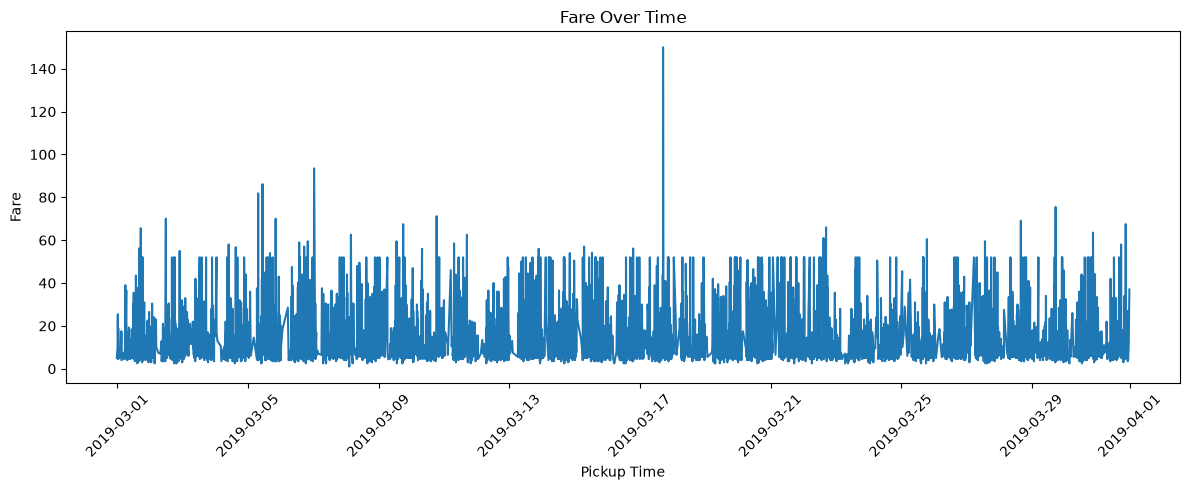

In [4]:
# Line Chart: fare over time
df['pickup'] = pd.to_datetime(df['pickup'])
df_sorted = df.sort_values('pickup')

plt.figure(figsize=(12, 5))
plt.plot(df_sorted['pickup'], df_sorted['fare'])
plt.title('Fare Over Time')
plt.xlabel('Pickup Time')
plt.ylabel('Fare')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

pickup_borough
Bronx         2078.91
Brooklyn      6227.48
Manhattan    58323.92
Queens       15541.06
Name: fare, dtype: float64


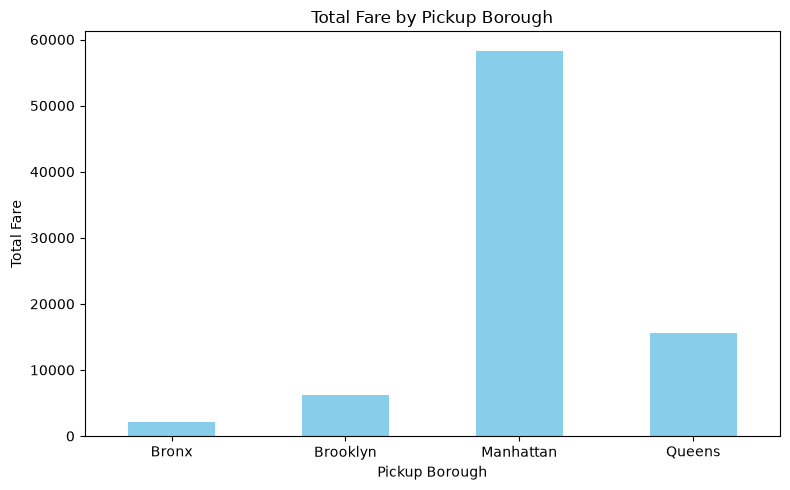

In [5]:
# Bar Chart: total fare for each pickup borough
borough_fare = df.groupby('pickup_borough')['fare'].sum()
print(borough_fare)

borough_fare.plot(kind='bar', figsize=(8, 5), color='skyblue')
plt.title('Total Fare by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

payment
credit card    4588
cash           1795
Name: count, dtype: int64


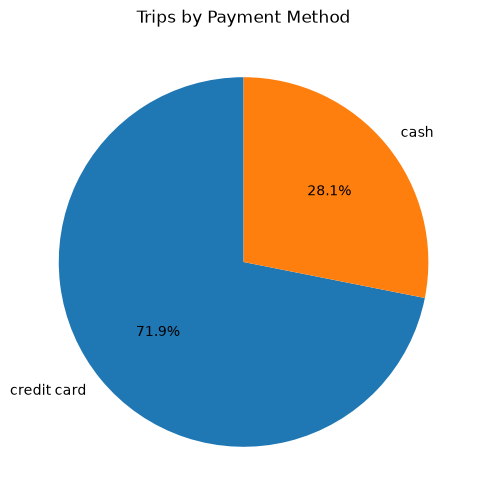

In [6]:
# Pie Chart: distribution of trips by payment method
payment_counts = df['payment'].value_counts()
print(payment_counts)

plt.figure(figsize=(6, 6))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Trips by Payment Method')
plt.show()

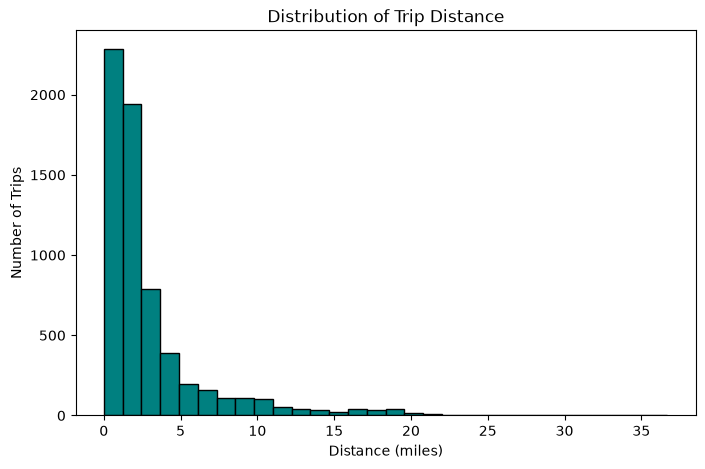

In [7]:
# Histogram: distribution of distance
plt.figure(figsize=(8, 5))
plt.hist(df['distance'], bins=30, color='teal', edgecolor='black')
plt.title('Distribution of Trip Distance')
plt.xlabel('Distance (miles)')
plt.ylabel('Number of Trips')
plt.show()

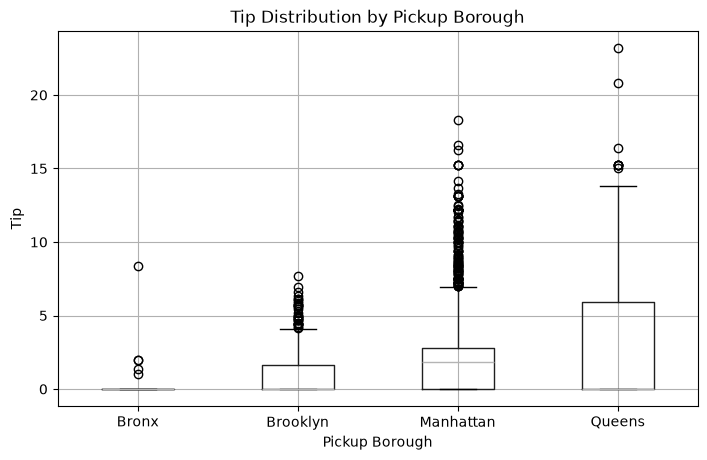

In [8]:
# Box Plot: tip amounts for each pickup borough
df.boxplot(column='tip', by='pickup_borough', figsize=(8, 5))
plt.title('Tip Distribution by Pickup Borough')
plt.suptitle('')
plt.xlabel('Pickup Borough')
plt.ylabel('Tip')
plt.show()

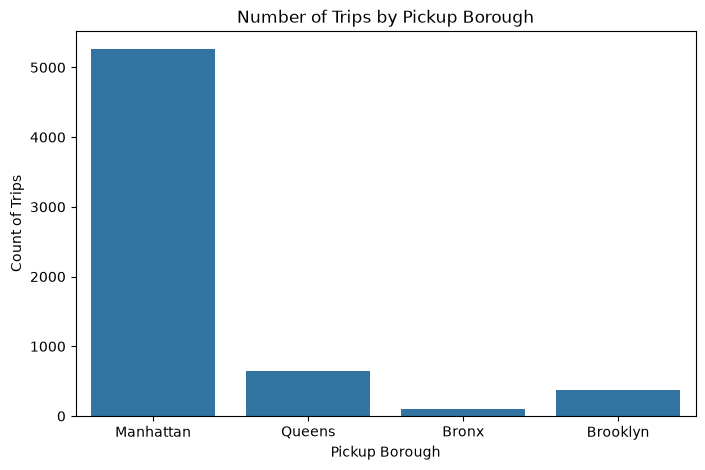

In [9]:
# Count Plot: number of trips in each pickup borough
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='pickup_borough')
plt.title('Number of Trips by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Count of Trips')
plt.show()

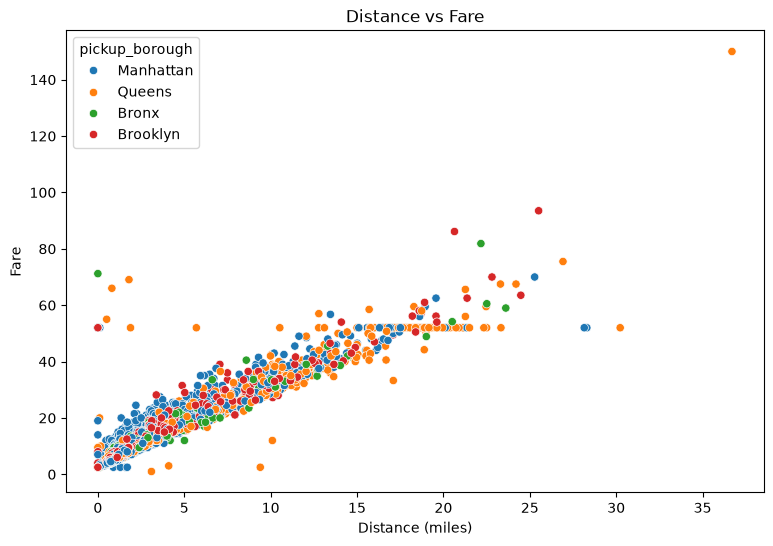

In [10]:
# Scatter Plot: distance vs fare, colored by pickup borough
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='distance', y='fare', hue='pickup_borough')
plt.title('Distance vs Fare')
plt.xlabel('Distance (miles)')
plt.ylabel('Fare')
plt.show()

          distance      fare       tip     tolls     total
distance  1.000000  0.947021  0.475378  0.642899  0.928371
fare      0.947021  1.000000  0.485655  0.618184  0.972376
tip       0.475378  0.485655  1.000000  0.412787  0.649050
tolls     0.642899  0.618184  0.412787  1.000000  0.691506
total     0.928371  0.972376  0.649050  0.691506  1.000000


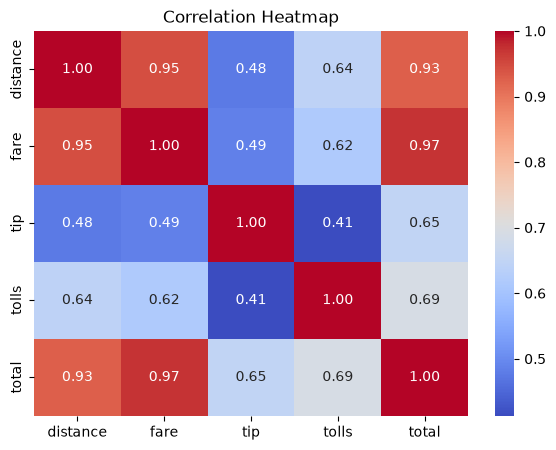

In [11]:
# Heatmap: correlation between numerical variables
corr = df[['distance', 'fare', 'tip', 'tolls', 'total']].corr()
print(corr)

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

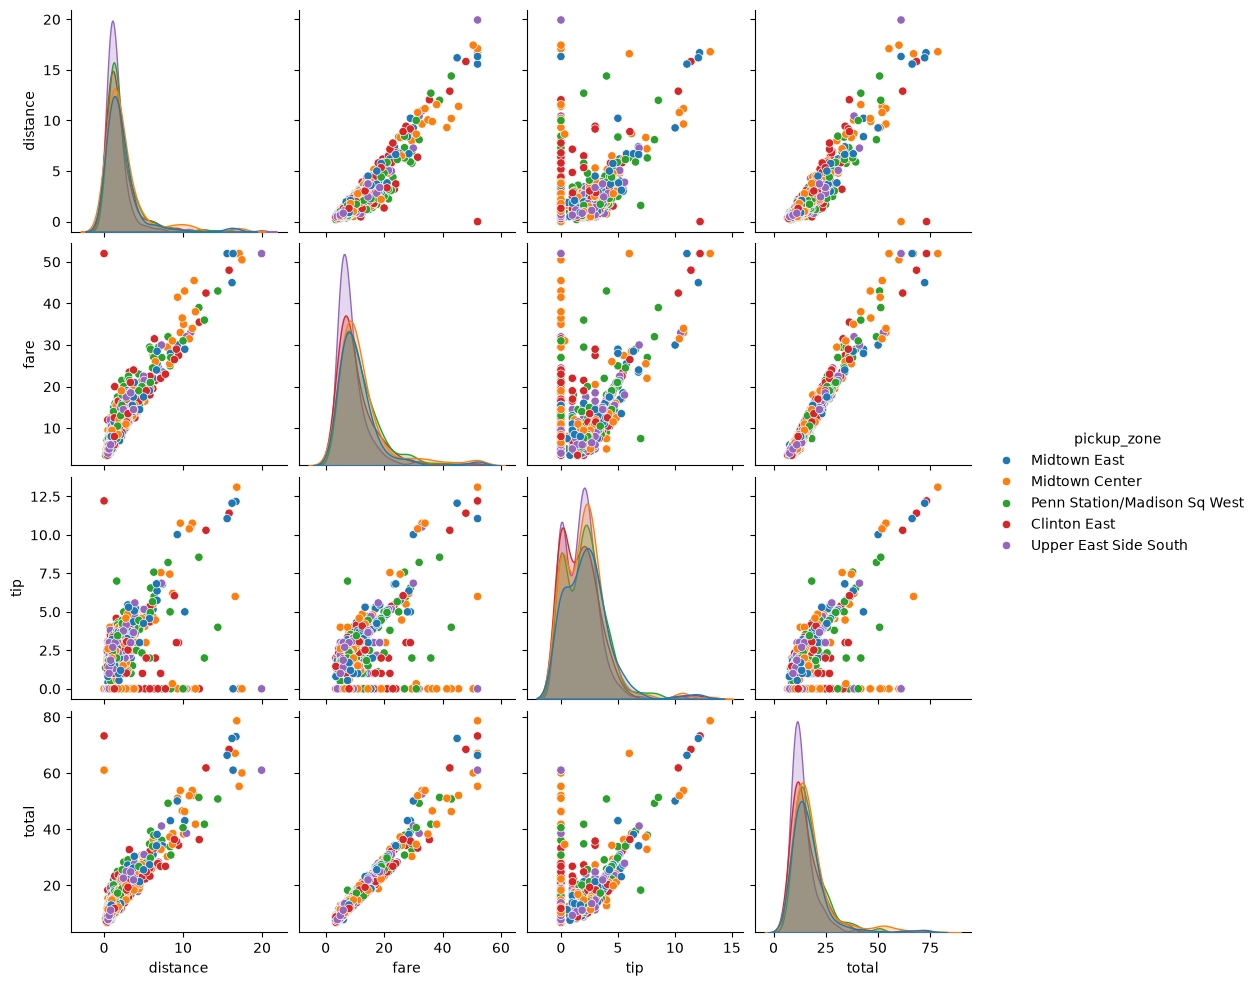

In [12]:
# Pair Plot: distance, fare, tip, total, colored by pickup_zone
top_zones = df['pickup_zone'].value_counts().head(5).index
df_pair = df[df['pickup_zone'].isin(top_zones)]

sns.pairplot(df_pair, vars=['distance', 'fare', 'tip', 'total'], hue='pickup_zone')
plt.show()

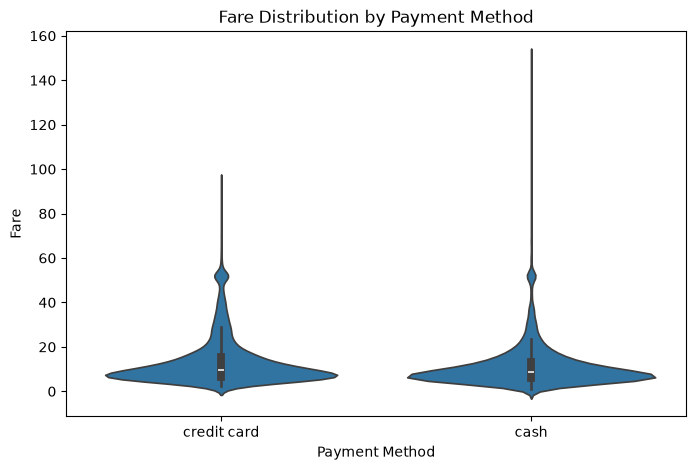

In [13]:
# Violin Plot: distribution of fare for each payment method
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='payment', y='fare')
plt.title('Fare Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.show()